# 04 Data Visualization

This notebook visualizes the cleaned Superstore sales dataset to identify trends, compare business performance across different dimensions, and communicate insights through charts.

The visualizations created in this notebook will support business decision-making and serve as a summary of the exploratory data analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned/superstore_cleaned.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2019-152156,2019-11-08,2019-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2019-152156,2019-11-08,2019-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2019-138688,2019-06-12,2019-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2018-108966,2018-10-11,2018-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2018-108966,2018-10-11,2018-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Sales by Region

This visualization compares total sales generated across each region.

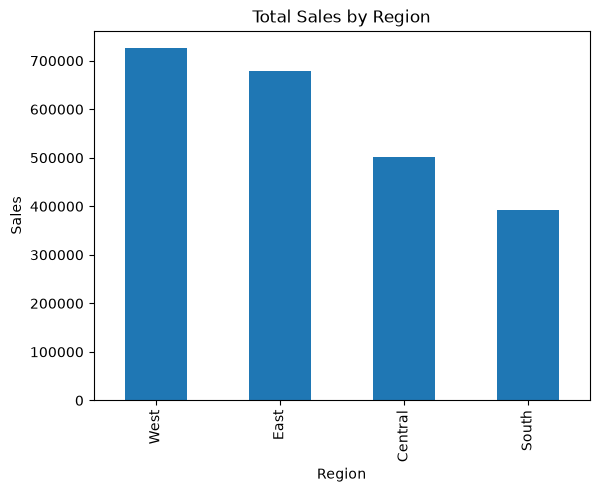

In [4]:
sales_by_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_region.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

## Profit by Category

This chart compares total profit across product categories.

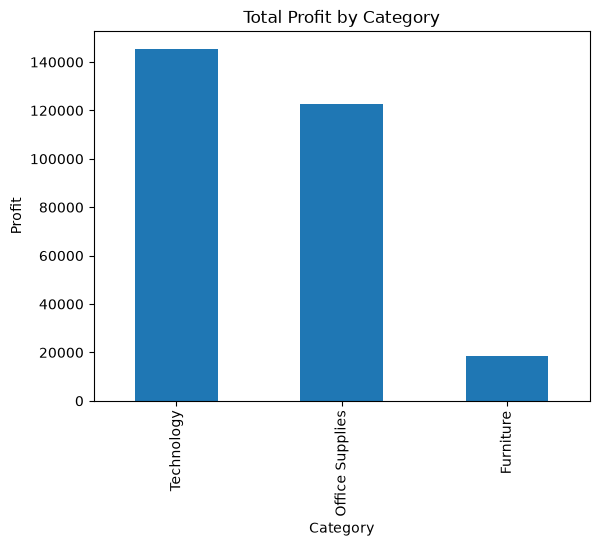

In [5]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_category.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

## Monthly Sales Trend

Analyze how sales changed over time.

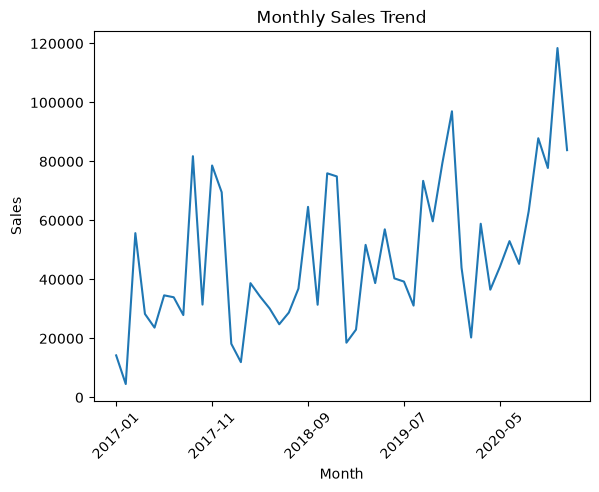

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot(kind="line")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

## Top 10 Customers

Identify the customers generating the highest sales.

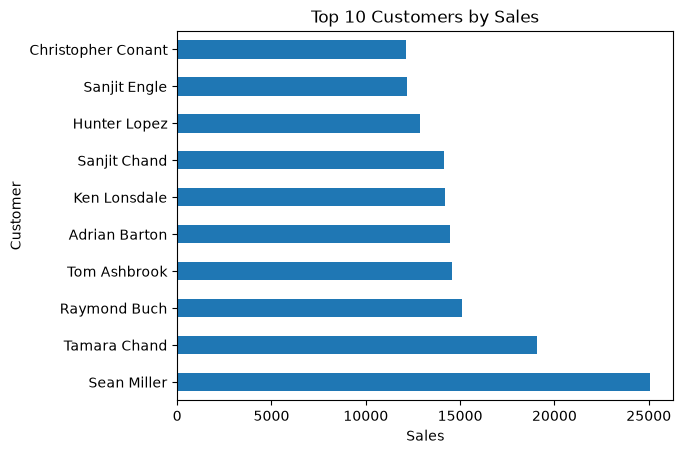

In [7]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.show()

# Visualization Summary

### Key Findings

- The West region generated the highest total sales.
- Technology produced the greatest profit.
- Sales fluctuated over time with noticeable seasonal peaks.
- A relatively small number of customers contributed a significant portion of total sales.

These visualizations summarize the primary business insights identified during exploratory data analysis.